In [4]:
import flwr as fl
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from typing import Dict, List, Optional, Tuple, Union
import warnings
import json
import time
import matplotlib.pyplot as plt
import os
warnings.filterwarnings('ignore')

print(f"Flower version: {fl.__version__}")
print("Imports completados ✓")
print()
print("EXPERIMENTO FEDERADO - TESIS FL-IDS")
print("=" * 50)
print("Dataset:    CIC-IDS-2018 (Bot vs Benign)")
print("Nodos:      5 (Non-IID)")
print("Algoritmo:  Logistic Regression + FedAvg")
print("Rondas:     10")
print()
print("Nota: Se usa Logistic Regression en lugar de")
print("Random Forest porque Flower necesita parámetros")
print("como arrays de NumPy, lo cual es nativo en LR.")

Flower version: 1.29.0
Imports completados ✓

EXPERIMENTO FEDERADO - TESIS FL-IDS
Dataset:    CIC-IDS-2018 (Bot vs Benign)
Nodos:      5 (Non-IID)
Algoritmo:  Logistic Regression + FedAvg
Rondas:     10

Nota: Se usa Logistic Regression en lugar de
Random Forest porque Flower necesita parámetros
como arrays de NumPy, lo cual es nativo en LR.


In [5]:
def obtener_parametros_lr(modelo):
    """Extrae parámetros del modelo como lista de arrays NumPy"""
    if hasattr(modelo, 'coef_'):
        return [modelo.coef_, modelo.intercept_]
    else:
        # Modelo no entrenado aún, devolver arrays vacíos
        return [np.array([]), np.array([])]

def asignar_parametros_lr(modelo, parametros):
    """Asigna parámetros recibidos al modelo local"""
    if len(parametros[0]) > 0:
        modelo.coef_ = parametros[0]
        modelo.intercept_ = parametros[1]
        # Necesario para que predict funcione
        modelo.classes_ = np.array([0, 1])
    return modelo

def cargar_datos_nodo(nodo_id: int):
    """Carga y prepara los datos de un nodo específico"""
    ruta = f'../datos/nodos/nodo_{nodo_id}.csv'
    df = pd.read_csv(ruta)
    
    X = df.drop('Label', axis=1).values.astype(np.float32)
    y = df['Label'].values
    
    # Dividir en train/test local
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

print("Funciones auxiliares definidas ✓")

# Verificar que los datos cargan correctamente
print("\nVerificando carga de nodos:")
for i in range(1, 6):
    X_tr, X_te, y_tr, y_te = cargar_datos_nodo(i)
    print(f"  Nodo {i}: train={len(X_tr):,} | test={len(X_te):,}")

Funciones auxiliares definidas ✓

Verificando carga de nodos:
  Nodo 1: train=167,123 | test=41,781
  Nodo 2: train=167,124 | test=41,781
  Nodo 3: train=167,123 | test=41,781
  Nodo 4: train=167,123 | test=41,781
  Nodo 5: train=128,679 | test=32,170


In [7]:
class ClienteDeteccionIntrusiones(fl.client.NumPyClient):
    """
    Cliente federado que representa un segmento de red de la UPEA.
    Cada instancia tiene sus propios datos locales y entrena
    un modelo sin compartir esos datos con el servidor.
    """
    
    def __init__(self, nodo_id: int):
        self.nodo_id = nodo_id
        self.X_train, self.X_test, self.y_train, self.y_test = \
            cargar_datos_nodo(nodo_id)
        
        # Modelo local - Logistic Regression
        self.modelo = LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced',
            solver='lbfgs'
        )
        
        nombres = {
            1: "Área administrativa",
            2: "Laboratorios",
            3: "Biblioteca y aulas", 
            4: "Docentes",
            5: "Servicios institucionales"
        }
        self.nombre = nombres[nodo_id]
    
    def get_parameters(self, config):
        """Devuelve parámetros actuales al servidor"""
        return obtener_parametros_lr(self.modelo)
    
    def fit(self, parameters, config):
        """
        Recibe parámetros del servidor,
        entrena localmente, devuelve parámetros actualizados.
        Los DATOS nunca salen de este nodo.
        """
        # Asignar parámetros globales si ya fueron inicializados
        if len(parameters[0]) > 0:
            self.modelo = asignar_parametros_lr(self.modelo, parameters)
        
        # Entrenar con datos locales
        self.modelo.fit(self.X_train, self.y_train)
        
        # Devolver: parámetros actualizados, cantidad de datos, métricas
        return (
            obtener_parametros_lr(self.modelo),
            len(self.X_train),
            {"nodo": self.nodo_id}
        )
    
    def evaluate(self, parameters, config):
        """Evalúa el modelo global con datos locales de prueba"""
        self.modelo = asignar_parametros_lr(self.modelo, parameters)
        
        y_pred = self.modelo.predict(self.X_test)
        
        f1 = f1_score(self.y_test, y_pred, 
                      average='macro', zero_division=0)
        precision = precision_score(self.y_test, y_pred, 
                                    average='macro', zero_division=0)
        recall = recall_score(self.y_test, y_pred, 
                              average='macro', zero_division=0)
        
        # Loss = 1 - F1 (Flower necesita un valor de pérdida)
        loss = 1.0 - f1
        
        return (
            float(loss),
            len(self.X_test),
            {
                "f1": float(f1),
                "precision": float(precision),
                "recall": float(recall),
                "nodo_id": self.nodo_id
            }
        )

print("Clase ClienteDeteccionIntrusiones definida ✓")
print()
print("Funcionamiento:")
print("  fit()      → entrena localmente, devuelve parámetros")
print("  evaluate() → evalúa modelo global con datos locales")
print("  Los datos NUNCA salen del cliente ✓")

Clase ClienteDeteccionIntrusiones definida ✓

Funcionamiento:
  fit()      → entrena localmente, devuelve parámetros
  evaluate() → evalúa modelo global con datos locales
  Los datos NUNCA salen del cliente ✓


In [8]:
def crear_cliente(cid: str):
    """
    Flower llama esta función para crear cada cliente.
    cid es el ID del cliente como string ("0", "1", etc.)
    """
    nodo_id = int(cid) + 1  # Convertir "0" → nodo_1, "1" → nodo_2, etc.
    return ClienteDeteccionIntrusiones(nodo_id).to_client()

# Registro para guardar métricas por ronda
historial_rondas = {
    'ronda': [],
    'f1_promedio': [],
    'precision_promedio': [],
    'recall_promedio': []
}

def agregar_metricas(metricas: List[Tuple[int, fl.common.Metrics]]):
    """
    Función de agregación de métricas personalizada.
    Flower la llama después de cada ronda de evaluación.
    """
    if not metricas:
        return {}
    
    # Calcular promedio ponderado por cantidad de datos de cada nodo
    total_ejemplos = sum(n for n, _ in metricas)
    
    f1_prom = sum(n * m["f1"] for n, m in metricas) / total_ejemplos
    prec_prom = sum(n * m["precision"] for n, m in metricas) / total_ejemplos
    rec_prom = sum(n * m["recall"] for n, m in metricas) / total_ejemplos
    
    # Guardar en historial
    historial_rondas['f1_promedio'].append(f1_prom)
    historial_rondas['precision_promedio'].append(prec_prom)
    historial_rondas['recall_promedio'].append(rec_prom)
    
    print(f"    F1={f1_prom:.4f} | "
          f"Precision={prec_prom:.4f} | "
          f"Recall={rec_prom:.4f}")
    
    return {
        "f1_promedio": f1_prom,
        "precision_promedio": prec_prom,
        "recall_promedio": rec_prom
    }

print("Funciones de simulación definidas ✓")

Funciones de simulación definidas ✓


In [9]:
NUM_RONDAS = 10
NUM_CLIENTES = 5

print("INICIANDO EXPERIMENTO FEDERADO")
print("=" * 50)
print(f"Nodos:          {NUM_CLIENTES}")
print(f"Rondas:         {NUM_RONDAS}")
print(f"Estrategia:     FedAvg (McMahan et al., 2017)")
print(f"Modelo base:    Logistic Regression")
print("=" * 50)
print()

inicio_experimento = time.time()

# Definir estrategia FedAvg
estrategia = fl.server.strategy.FedAvg(
    fraction_fit=1.0,          # Usar todos los clientes en cada ronda
    fraction_evaluate=1.0,     # Evaluar en todos los clientes
    min_fit_clients=5,         # Mínimo 5 clientes para entrenar
    min_evaluate_clients=5,    # Mínimo 5 clientes para evaluar
    min_available_clients=5,   # Esperar a que estén los 5 disponibles
    evaluate_metrics_aggregation_fn=agregar_metricas,
)

# Ejecutar simulación
print("Progreso por ronda:")
historial = fl.simulation.start_simulation(
    client_fn=crear_cliente,
    num_clients=NUM_CLIENTES,
    config=fl.server.ServerConfig(num_rounds=NUM_RONDAS),
    strategy=estrategia,
    client_resources={
        "num_cpus": 2,    # CPUs por cliente simulado
        "num_gpus": 0.0   # Sin GPU
    }
)

tiempo_total = time.time() - inicio_experimento

print()
print("=" * 50)
print(f"EXPERIMENTO COMPLETADO")
print(f"Tiempo total: {tiempo_total:.1f} segundos")
print(f"Rondas completadas: {NUM_RONDAS}")

if historial_rondas['f1_promedio']:
    f1_final = historial_rondas['f1_promedio'][-1]
    f1_maximo = max(historial_rondas['f1_promedio'])
    print(f"F1 final (ronda {NUM_RONDAS}): {f1_final:.4f}")
    print(f"F1 máximo alcanzado:          {f1_maximo:.4f}")
    print(f"Baseline centralizado:         1.0000")
    print(f"Diferencia vs centralizado:   "
          f"{(1.0 - f1_final)*100:.2f}%")

INICIANDO EXPERIMENTO FEDERADO
Nodos:          5
Rondas:         10
Estrategia:     FedAvg (McMahan et al., 2017)
Modelo base:    Logistic Regression

Progreso por ronda:


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-05-19 00:14:00,845	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 826356940.0, 'node:127.0.0.1': 1.0, 'memory': 1928166196.0, 'node:__internal_head__': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActor

    F1=0.9612 | Precision=0.9464 | Recall=0.9809


(ClientAppActor pid=4168) 
(ClientAppActor pid=4168) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 9x across cluster]
(ClientAppActor pid=4168)             This is a deprecated feature. It will be removed [repeated 9x across cluster]
(ClientAppActor pid=4168)             entirely in future versions of Flower. [repeated 9x across cluster]
(ClientAppActor pid=4168) c:\tesis-fl-ids\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
(ClientAppActor pid=4168) STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
(ClientAppActor pid=4168) Increase the number of iterations to improve the convergence (max_iter=1000).
(ClientAppActor pid=4168) You might also want to scale the data as shown in:
(ClientAppAc

    F1=0.9612 | Precision=0.9464 | Recall=0.9809


...

    F1=0.9612 | Precision=0.9464 | Recall=0.9809


(ClientAppActor pid=12644) 
(ClientAppActor pid=12644) c:\tesis-fl-ids\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
(ClientAppActor pid=12644) STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
(ClientAppActor pid=12644) Increase the number of iterations to improve the convergence (max_iter=1000).
(ClientAppActor pid=12644) You might also want to scale the data as shown in:
(ClientAppActor pid=12644)     https://scikit-learn.org/stable/modules/preprocessing.html
(ClientAppActor pid=12644) Please also refer to the documentation for alternative solver options:
(ClientAppActor pid=12644)     https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
(ClientAppActor pid=12644)   n_iter_i = _check_optimize_result(
(ClientAppActor pid=4168) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'ci

    F1=0.9612 | Precision=0.9464 | Recall=0.9809


(ClientAppActor pid=4168) 
(ClientAppActor pid=4168) c:\tesis-fl-ids\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
(ClientAppActor pid=4168) STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
(ClientAppActor pid=4168) Increase the number of iterations to improve the convergence (max_iter=1000).
(ClientAppActor pid=4168) You might also want to scale the data as shown in:
(ClientAppActor pid=4168)     https://scikit-learn.org/stable/modules/preprocessing.html
(ClientAppActor pid=4168) Please also refer to the documentation for alternative solver options:
(ClientAppActor pid=4168)     https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
(ClientAppActor pid=4168)   n_iter_i = _check_optimize_result(
(ClientAppActor pid=15032) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Par

    F1=0.9612 | Precision=0.9464 | Recall=0.9809

EXPERIMENTO COMPLETADO
Tiempo total: 1032.5 segundos
Rondas completadas: 10
F1 final (ronda 10): 0.9612
F1 máximo alcanzado:          0.9612
Baseline centralizado:         1.0000
Diferencia vs centralizado:   3.88%


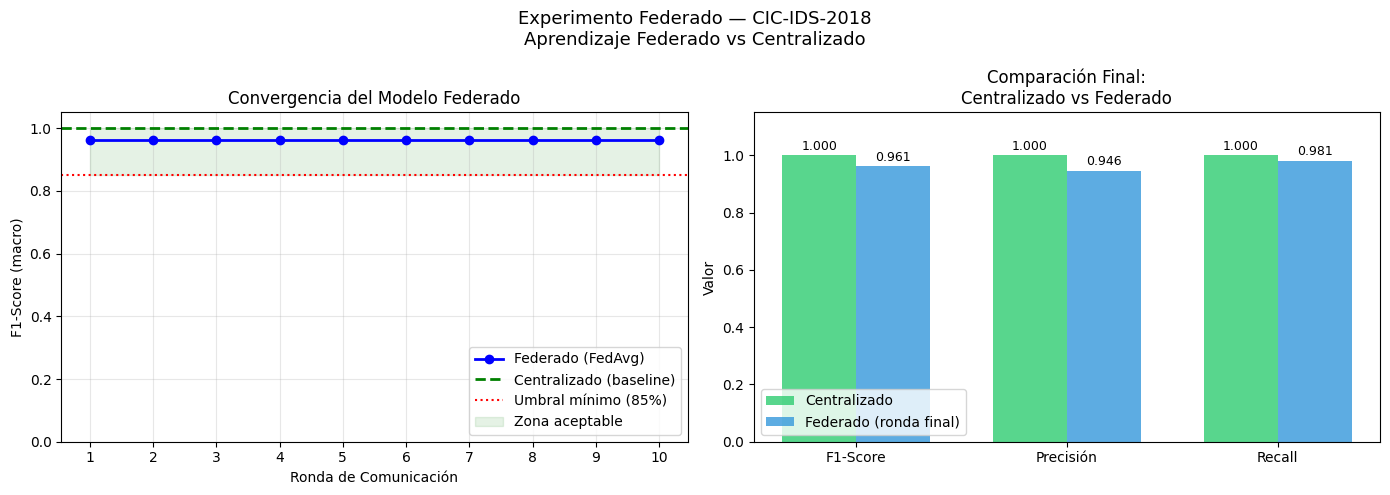

Gráfico guardado ✓


In [10]:
if historial_rondas['f1_promedio']:
    rondas = list(range(1, len(historial_rondas['f1_promedio']) + 1))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Experimento Federado — CIC-IDS-2018\n'
                 'Aprendizaje Federado vs Centralizado', 
                 fontsize=13)
    
    # Gráfico 1: Curva de aprendizaje F1
    ax1 = axes[0]
    ax1.plot(rondas, historial_rondas['f1_promedio'], 
             'b-o', linewidth=2, markersize=6, label='Federado (FedAvg)')
    ax1.axhline(y=1.0, color='g', linestyle='--', 
                linewidth=2, label='Centralizado (baseline)')
    ax1.axhline(y=0.85, color='r', linestyle=':', 
                linewidth=1.5, label='Umbral mínimo (85%)')
    ax1.fill_between(rondas, 0.85, 1.0, alpha=0.1, color='green',
                     label='Zona aceptable')
    ax1.set_xlabel('Ronda de Comunicación')
    ax1.set_ylabel('F1-Score (macro)')
    ax1.set_title('Convergencia del Modelo Federado')
    ax1.legend(loc='lower right')
    ax1.set_ylim([0, 1.05])
    ax1.set_xticks(rondas)
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Comparación de métricas finales
    ax2 = axes[1]
    metricas_nombres = ['F1-Score', 'Precisión', 'Recall']
    valores_federado = [
        historial_rondas['f1_promedio'][-1],
        historial_rondas['precision_promedio'][-1],
        historial_rondas['recall_promedio'][-1]
    ]
    valores_centralizado = [1.0, 1.0, 1.0]
    
    x = np.arange(len(metricas_nombres))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, valores_centralizado, width, 
                    label='Centralizado', color='#2ecc71', alpha=0.8)
    bars2 = ax2.bar(x + width/2, valores_federado, width,
                    label='Federado (ronda final)', 
                    color='#3498db', alpha=0.8)
    
    ax2.set_ylabel('Valor')
    ax2.set_title('Comparación Final:\nCentralizado vs Federado')
    ax2.set_xticks(x)
    ax2.set_xticklabels(metricas_nombres)
    ax2.legend()
    ax2.set_ylim([0, 1.15])
    
    for bar in bars1:
        ax2.text(bar.get_x() + bar.get_width()/2., 
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', 
                 ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax2.text(bar.get_x() + bar.get_width()/2., 
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', 
                 ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../resultados/experimento_federado_resultado.png', 
                dpi=150)
    plt.show()
    print("Gráfico guardado ✓")

In [ ]:
+*-
+






+++++9658499+9+98*--# Guardar resultados completos
resultados_federado = {
    'experimento': 'Aprendizaje Federado FedAvg',
    'num_rondas': NUM_RONDAS,
    'num_nodos': NUM_CLIENTES,
    'modelo_base': 'Logistic Regression',
    'dataset': 'CIC-IDS-2018 Friday Bot',
    'particion': 'Non-IID 5 nodos',
    'tiempo_total_seg': round(tiempo_total, 1),
    'baseline_centralizado_f1': 1.0,
    'f1_por_ronda': historial_rondas['f1_promedio'],
    'precision_por_ronda': historial_rondas['precision_promedio'],
    'recall_por_ronda': historial_rondas['recall_promedio'],
    'f1_final': round(historial_rondas['f1_promedio'][-1], 4),
    'f1_maximo': round(max(historial_rondas['f1_promedio']), 4),
    'diferencia_vs_centralizado_pct': round(
        (1.0 - historial_rondas['f1_promedio'][-1]) * 100, 2
    ),
    'hipotesis_cumplida': historial_rondas['f1_promedio'][-1] >= 0.85
}

with open('../resultados/resultados_federado.json', 'w') as f:
    json.dump(resultados_federado, f, indent=2)

print("RESUMEN EJECUTIVO DEL EXPERIMENTO")
print("=" * 50)
print(f"F1 Centralizado:    {resultados_federado['baseline_centralizado_f1']:.4f}")
print(f"F1 Federado final:  {resultados_federado['f1_final']:.4f}")
print(f"Diferencia:         {resultados_federado['diferencia_vs_centralizado_pct']:.2f}%")
print(f"Hipótesis cumplida: {resultados_federado['hipotesis_cumplida']}")
print()
print("Resultados guardados en resultados/resultados_federado.json ✓")

# Commit
import subprocess
for cmd in [
    ['git', 'add', '.'],
    ['git', 'commit', '-m', 
     f"feat: experimento federado F1={resultados_federado['f1_final']} "
     f"rondas={NUM_RONDAS}"],
    ['git', 'push']
]:
    r = subprocess.run(cmd, cwd='C:/tesis-fl-ids', 
                       capture_output=True, text=True)
    if r.returncode == 0:
        print(f"✓ git {cmd[1]}")
    else:
        print(f"Info: {r.stderr[:80]}")

RESUMEN EJECUTIVO DEL EXPERIMENTO
F1 Centralizado:    1.0000
F1 Federado final:  0.9612
Diferencia:         3.88%
Hipótesis cumplida: True

Resultados guardados en resultados/resultados_federado.json ✓
✓ git add
✓ git commit
✓ git push
